# TP N°2 : Classification avec des Réseaux de Neurones Entièrement Connectés

**Deep Learning - Oussama Ghazouani**   


---


Dans ce TP, nous allons résoudre des problèmes de classification avec des **réseaux de neurones FCNN (Fully Connected Neural Networks)**.


---



## Imports et Configuration Globale

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.preprocessing import LabelBinarizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import Callback


np.random.seed(42)
tf.random.set_seed(42)


#verification des versions TF et Keras
print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')

TensorFlow version : 2.21.0
Keras version      : 3.13.2


---
# Partie I — Classification Binaire

Nous allons construire un classificateur binaire capable de distinguer deux classes circulaires concentriques générées par `make_circles`.

## 1. Dataset

### 1.a  Création du dataset avec `make_circles()`

In [68]:
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
#affichage des dimensions
print(f'  X shape : {X.shape}')
print(f'  y shape : {y.shape}')
print(f'  Classes présentes : {np.unique(y)}')
print(f'  Distribution des classes : Classe 0 → {np.sum(y==0)}, Classe 1 → {np.sum(y==1)}')

  X shape : (1000, 2)
  y shape : (1000,)
  Classes présentes : [0 1]
  Distribution des classes : Classe 0 → 500, Classe 1 → 500


### 1.b  Dimensions du dataset

**Analyse des dimensions :**
- **Entrée ** : `X` a la forme `(1000, 2)` -> 2 features par échantillon ($x_1$, $x_2$), donc l'entrée du classificateur est de **dimension 2**.
- **Sortie ** : `y` a la forme `(1000,)`-> scalaire binaire (0 ou 1), donc la sortie est de **dimension 1**.

Le classifieur prend en entrée un vecteur $[x_1, x_2]$ et produit une prédiction binaire soit 0 soit 1.

### 1.c Visualisation des données

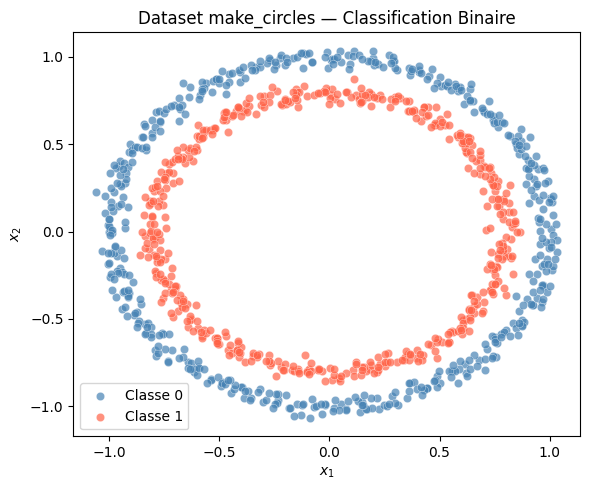

In [69]:
plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Classe 0', alpha=0.7, edgecolors='white', linewidths=0.3)
plt.scatter(X[y==1, 0], X[y==1, 1], c='tomato',    label='Classe 1', alpha=0.7, edgecolors='white', linewidths=0.3)
plt.title('Dataset make_circles — Classification Binaire')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.tight_layout()
plt.show()

### 1.d  Linéaire ou non linéaire ?

> **Réponse : Ce dataset nécessite une fonction de décision non lineaire.**
>
> La visualisation montre clairement que la **Classe 0** forme un cercle intérieur et la **Classe 1** un cercle extérieur. il est impossible de les separer linéairement. Une frontière de décision **non linéaire**  est nécessaire.

### 1.e  Division Train / Test

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



---
## 2. Définition du Modèle


### 2.2  Définition du modèle FCNN

L'architecture   est :
- **Entrée** : 2 neurones ($x_1$, $x_2$)
- **Couche cachée** : 100 neurones + activation **Sigmoïde**
- **Couche de sortie** : 1 neurone + activation **Sigmoïde** (classification binaire)



In [71]:
model = Sequential(name='FCNN_Binaire_v1')

#hidden layer
model.add(Dense(100, activation='sigmoid', input_shape=(2,), name='hidden_layer'))

#output layer
model.add(Dense(1, activation='sigmoid', name='output_layer'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FCNN_Binaire_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3  Compilation du modèle

- **Fonction de perte** : `binary_crossentropy`
- **Optimiseur** : `SGD`
- **Métrique** : `accuracy`

In [72]:
model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Modèle compilé avec succès.')


Modèle compilé avec succès.


### 2.4  Entraînement du modèle

Entraînement sur 100 époques, avec affichage toutes les 10 époques .

In [73]:
# Callback personnalisé pour afficher la progression chaque 10 epoques
class PrintEvery10Epochs(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(f"Époque {epoch+1:3d}/100  "
                  f"| Loss: {logs['loss']:.4f}  "
                  f"| Accuracy: {logs['accuracy']:.4f}  "
                  f"| Val Loss: {logs['val_loss']:.4f}  "
                  f"| Val Accuracy: {logs['val_accuracy']:.4f}")

print("Début de l'entraînement \n")
history_v1 = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0,
    callbacks=[PrintEvery10Epochs()]
)
print('\nEntraînement terminé ')

Début de l'entraînement 

Époque  10/100  | Loss: 0.6938  | Accuracy: 0.4913  | Val Loss: 0.6938  | Val Accuracy: 0.4800
Époque  20/100  | Loss: 0.6938  | Accuracy: 0.4825  | Val Loss: 0.6938  | Val Accuracy: 0.4700
Époque  30/100  | Loss: 0.6938  | Accuracy: 0.4800  | Val Loss: 0.6939  | Val Accuracy: 0.4700
Époque  40/100  | Loss: 0.6938  | Accuracy: 0.4825  | Val Loss: 0.6939  | Val Accuracy: 0.4650
Époque  50/100  | Loss: 0.6938  | Accuracy: 0.4900  | Val Loss: 0.6940  | Val Accuracy: 0.4650
Époque  60/100  | Loss: 0.6937  | Accuracy: 0.4900  | Val Loss: 0.6940  | Val Accuracy: 0.4650
Époque  70/100  | Loss: 0.6937  | Accuracy: 0.4875  | Val Loss: 0.6941  | Val Accuracy: 0.4550
Époque  80/100  | Loss: 0.6937  | Accuracy: 0.4825  | Val Loss: 0.6941  | Val Accuracy: 0.4400
Époque  90/100  | Loss: 0.6937  | Accuracy: 0.4900  | Val Loss: 0.6941  | Val Accuracy: 0.4400
Époque 100/100  | Loss: 0.6937  | Accuracy: 0.4900  | Val Loss: 0.6942  | Val Accuracy: 0.4500

Entraînement terminé 


### 2.5  Évaluation du modèle

#### Courbes d'apprentissage

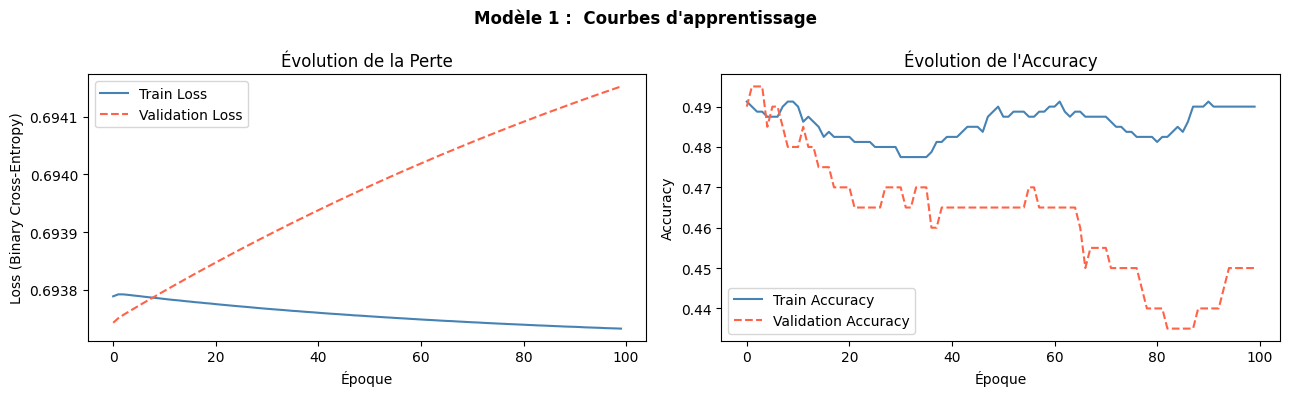

Score final — Train : Loss=0.6930, Accuracy=0.4925
Score final — Test  : Loss=0.6942,  Accuracy=0.4500


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Courbe de perte
axes[0].plot(history_v1.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history_v1.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Évolution de la Perte')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss (Binary Cross-Entropy)')
axes[0].legend()

# Courbe d'accuracy
axes[1].plot(history_v1.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history_v1.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title("Évolution de l'Accuracy")
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Modèle 1 :  Courbes d\'apprentissage', fontweight='bold')
plt.tight_layout()
plt.show()

# Score final
loss_train, acc_train = model.evaluate(X_train, y_train, verbose=0)
loss_test,  acc_test  = model.evaluate(X_test,  y_test,  verbose=0)
print(f'Score final — Train : Loss={loss_train:.4f}, Accuracy={acc_train:.4f}')
print(f'Score final — Test  : Loss={loss_test:.4f},  Accuracy={acc_test:.4f}')

#### Frontières de décision : Modèle 1

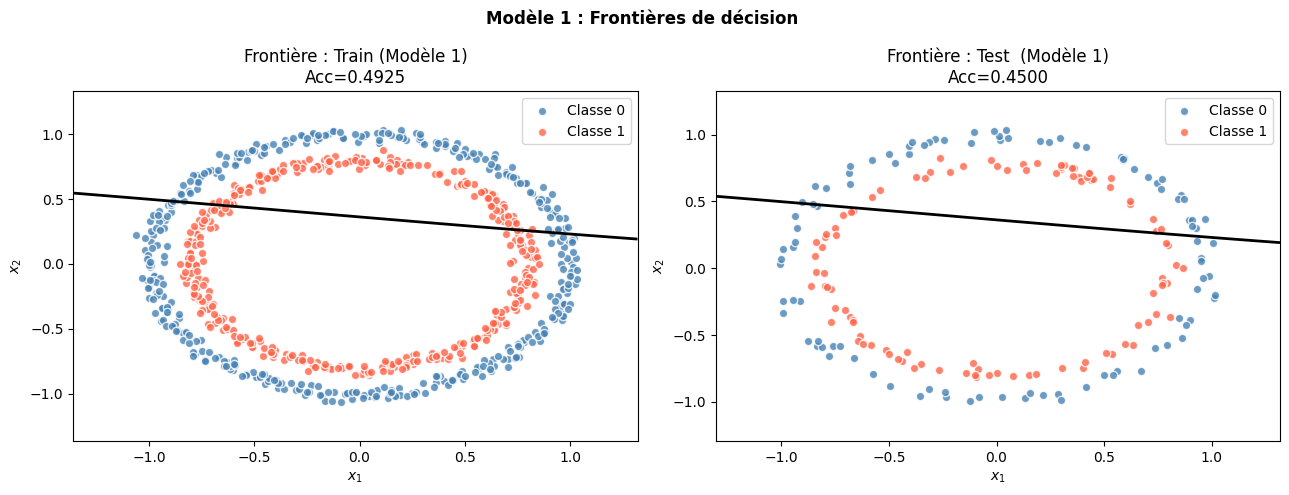

In [75]:
def plot_decision_boundary(model, X, y, title='Frontière de décision', ax=None):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict(grid, verbose=0).reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # On ne garde que la ligne de décision (0.5) sans le remplissage dégradé
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)

    ax.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Classe 0', edgecolors='white', alpha=0.8)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='tomato',    label='Classe 1', edgecolors='white', alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper right')
    return ax

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(model, X_train, y_train, title=f'Frontière : Train (Modèle 1)\nAcc={acc_train:.4f}', ax=axes[0])
plot_decision_boundary(model, X_test,  y_test,  title=f'Frontière : Test  (Modèle 1)\nAcc={acc_test:.4f}',  ax=axes[1])
plt.suptitle('Modèle 1 : Frontières de décision ', fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.5.2  Problème identifié avec ce modèle

**Problème : underfitting**
>
> Le modèle 1 présente les symptômes suivants :
> - La frontière de décision est linéaire.
> - La **précision est Trés faible** (autour de 48%)
> - La **sigmoïde** dans la couche cachée souffre du **problème de gradient évanescent** (*vanishing gradient*)
> - Le **SGD** sans momentum converge lentement et peut se bloquer dans des minima locaux.
> - La **seule couche cachée** limite la capacité d'approximation du modèle.
#### 2.5.3 — Trois techniques d'amélioration

1. **Remplacer Sigmoïde : ReLU dans la couche cachée**  
   ReLU évite le gradient évanescent et accélère la convergence.

2. **Remplacer SGD : Adam**  
   Adam adapte le taux d'apprentissage automatiquement et converge plus vite.

3. **Ajouter des couches cachées supplémentaires**  
   Augmente la capacité d'approximation du modèle

#### Implémentation du modèle amélioré (Modèle 2)

In [76]:
# ReLU + hidden_layers supplémentaires + Adam
model_v2 = Sequential(name='FCNN_Binaire_v2_Improved')

model_v2.add(Dense(64, activation='relu', input_shape=(2,), name='hidden_1'))
model_v2.add(Dense(64, activation='relu', name='hidden_2'))
model_v2.add(Dense(32, activation='relu', name='hidden_3'))
model_v2.add(Dense(1,  activation='sigmoid', name='output'))

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "FCNN_Binaire_v2_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
print("Entraînement du modèle 2 amélioré...\n")
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0,
    callbacks=[PrintEvery10Epochs()]
)
print('\nEntraînement 2 terminé.')

Entraînement du modèle 2 amélioré...

Époque  10/100  | Loss: 0.2658  | Accuracy: 0.9875  | Val Loss: 0.2512  | Val Accuracy: 0.9950
Époque  20/100  | Loss: 0.0143  | Accuracy: 1.0000  | Val Loss: 0.0272  | Val Accuracy: 1.0000
Époque  30/100  | Loss: 0.0051  | Accuracy: 1.0000  | Val Loss: 0.0136  | Val Accuracy: 1.0000
Époque  40/100  | Loss: 0.0027  | Accuracy: 1.0000  | Val Loss: 0.0103  | Val Accuracy: 1.0000
Époque  50/100  | Loss: 0.0017  | Accuracy: 1.0000  | Val Loss: 0.0082  | Val Accuracy: 1.0000
Époque  60/100  | Loss: 0.0012  | Accuracy: 1.0000  | Val Loss: 0.0066  | Val Accuracy: 1.0000
Époque  70/100  | Loss: 0.0009  | Accuracy: 1.0000  | Val Loss: 0.0055  | Val Accuracy: 1.0000
Époque  80/100  | Loss: 0.0007  | Accuracy: 1.0000  | Val Loss: 0.0047  | Val Accuracy: 1.0000
Époque  90/100  | Loss: 0.0006  | Accuracy: 1.0000  | Val Loss: 0.0041  | Val Accuracy: 1.0000
Époque 100/100  | Loss: 0.0004  | Accuracy: 1.0000  | Val Loss: 0.0035  | Val Accuracy: 1.0000

Entraînemen

                     Modèle v1       Modèle v2      
Train Accuracy       0.4925          1.0000
Test Accuracy        0.4500          1.0000


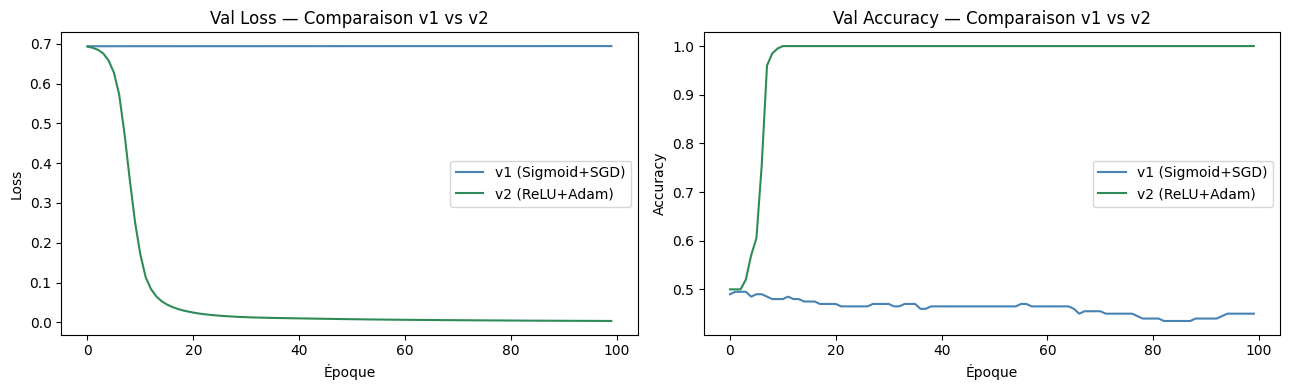

In [78]:
loss_train_v2, acc_train_v2 = model_v2.evaluate(X_train, y_train, verbose=0)
loss_test_v2,  acc_test_v2  = model_v2.evaluate(X_test,  y_test,  verbose=0)

# Comparaison des deux modèles
print('='*55)
print(f'{"":20} {"Modèle v1":15} {"Modèle v2":15}')
print('='*55)
print(f'{"Train Accuracy":20} {acc_train:.4f}          {acc_train_v2:.4f}')
print(f'{"Test Accuracy":20} {acc_test:.4f}          {acc_test_v2:.4f}')
print('='*55)

# Courbes de comparaison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for h, label, color in [(history_v1, 'v1 (Sigmoid+SGD)', 'steelblue'),
                         (history_v2, 'v2 (ReLU+Adam)',   'seagreen')]:
    axes[0].plot(h.history['val_loss'],     label=label, color=color)
    axes[1].plot(h.history['val_accuracy'], label=label, color=color)

axes[0].set_title('Val Loss — Comparaison v1 vs v2')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].set_title('Val Accuracy — Comparaison v1 vs v2')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

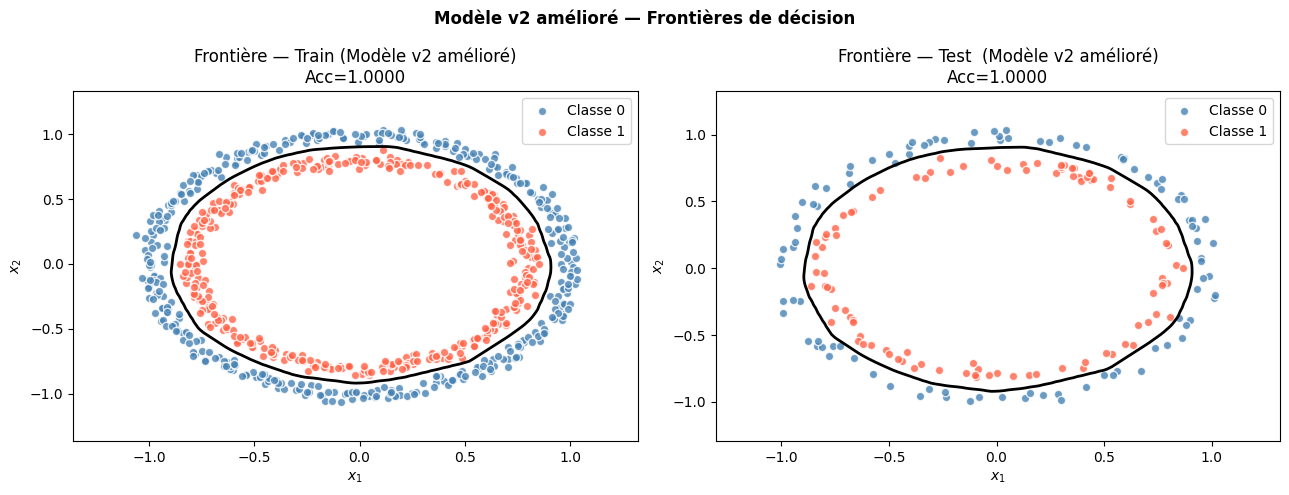

In [79]:
# Frontières de décision — Modèle v2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(model_v2, X_train, y_train,
                       title=f'Frontière — Train (Modèle v2 amélioré)\nAcc={acc_train_v2:.4f}', ax=axes[0])
plot_decision_boundary(model_v2, X_test,  y_test,
                       title=f'Frontière — Test  (Modèle v2 amélioré)\nAcc={acc_test_v2:.4f}',  ax=axes[1])
plt.suptitle('Modèle v2 amélioré — Frontières de décision', fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusion Partie I :**

> Le modèle v2 (3 couches ReLU + optimiseur Adam) atteint une précision parfaite de **100%** sur les données circulaires, contre une précision limitée pour le modèle v1 (Sigmoïde + SGD) (proche de 48%).
- > Les frontières de décision du v2 épousent parfaitement la structure circulaire des données, démontrant l'importance du choix de la fonction d'activation et de l'optimiseur.

---
# Partie II — Multi-Classification

Nous allons construire un classificateur capable de distinguer **4 classes** générées avec `make_blobs`.

## 1. Création du Dataset Multi-Classes

In [80]:
X_mc, y_mc = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    cluster_std=1.0,
    random_state=42
)



## 2. Division Train / Test

In [81]:
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc,
    test_size=0.2,
    random_state=42
)



## 3. Visualisation des données

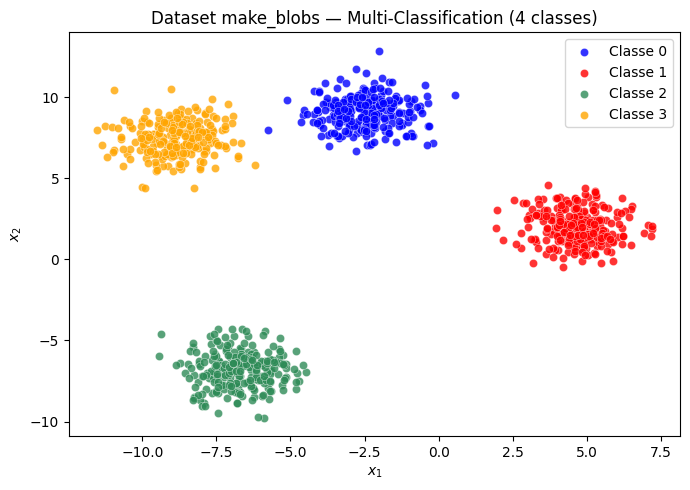

In [82]:
colors = ['blue', 'red', 'seagreen', 'orange']
plt.figure(figsize=(7, 5))
for cls in range(4):
    mask = y_mc == cls
    plt.scatter(X_mc[mask, 0], X_mc[mask, 1],
                c=colors[cls], label=f'Classe {cls}',
                alpha=0.8, edgecolors='white', linewidths=0.3, s=35)
plt.title('Dataset make_blobs — Multi-Classification (4 classes)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Linéaire ou non linéaire ?

 **Réponse : Ce dataset peut être séparé avec des frontières linéaires.**

> La visualisation montre que les classes sont **bien séparés dans l'espace** et que chaque groupe forme un nuage compact. Des frontières de décision **linéaires par morceaux** (que produit un réseau ReLU) suffisent généralement. Cependant, un réseau FCNN avec quelques couches cachées sera plus robuste, surtout si les classes se chevauchent légèrement au cas ou on change les paramétres.

## 5. Architecture FCNN pour la Multi-Classification

**Choix de design :**
- **Entrée** : 2 neurones ($x_1$, $x_2$)
- **Couches cachées** : 2 couches Dense (64 neurones, ReLU) , capacité suffisante pour des blobs
- **Couche de sortie** : 4 neurones + activation **Softmax**
- **Fonction de perte** : `sparse_categorical_crossentropy` (plus pratique que le categorical_crossentropy, car la sortie est non encodée)
- **Optimiseur** : Adam

In [83]:
model_mc = Sequential(name='FCNN_MultiClass')

model_mc.add(Dense(64, activation='relu', input_shape=(2,), name='hidden_1'))
model_mc.add(Dense(64, activation='relu',                   name='hidden_2'))
model_mc.add(Dense(4,  activation='softmax',               name='output'))

model_mc.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_mc.summary()

Model: "FCNN_MultiClass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,612 (18.02 KB)

 Trainable params: 4,612 (18.02 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entraînement du modèle

100 époques avec affichage toutes les 10 époques.

Debut de l'entraînement 

Époque  10/100  | Loss: 0.0050  | Accuracy: 0.9987  | Val Loss: 0.0034  | Val Accuracy: 1.0000
Époque  20/100  | Loss: 0.0029  | Accuracy: 0.9987  | Val Loss: 0.0015  | Val Accuracy: 1.0000
Époque  30/100  | Loss: 0.0024  | Accuracy: 0.9987  | Val Loss: 0.0010  | Val Accuracy: 1.0000
Époque  40/100  | Loss: 0.0022  | Accuracy: 0.9987  | Val Loss: 0.0007  | Val Accuracy: 1.0000
Époque  50/100  | Loss: 0.0021  | Accuracy: 0.9987  | Val Loss: 0.0006  | Val Accuracy: 1.0000
Époque  60/100  | Loss: 0.0020  | Accuracy: 0.9987  | Val Loss: 0.0005  | Val Accuracy: 1.0000
Époque  70/100  | Loss: 0.0019  | Accuracy: 0.9987  | Val Loss: 0.0004  | Val Accuracy: 1.0000
Époque  80/100  | Loss: 0.0019  | Accuracy: 0.9987  | Val Loss: 0.0003  | Val Accuracy: 1.0000
Époque  90/100  | Loss: 0.0018  | Accuracy: 0.9987  | Val Loss: 0.0003  | Val Accuracy: 1.0000
Époque 100/100  | Loss: 0.0017  | Accuracy: 0.9987  | Val Loss: 0.0002  | Val Accuracy: 1.0000

Entraînement terminé


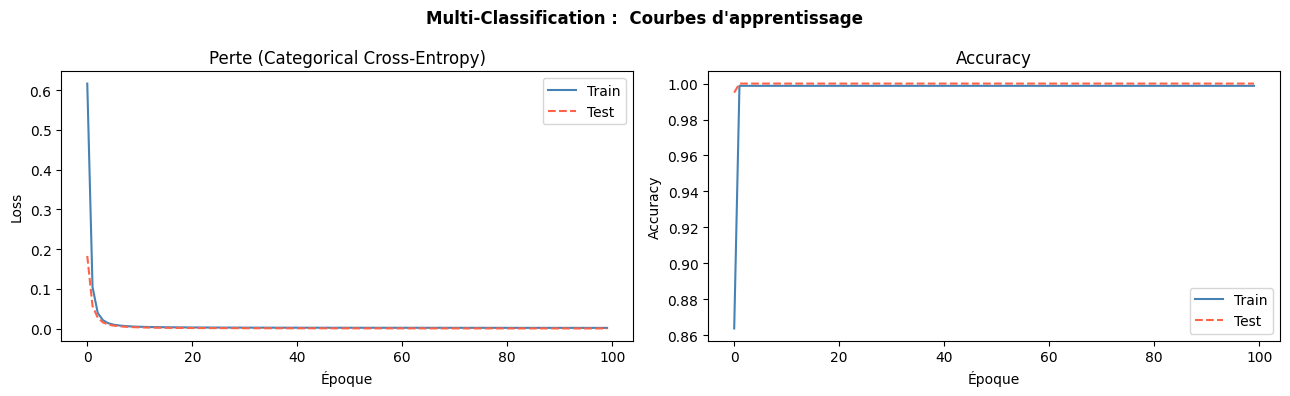

In [84]:
print("Debut de l'entraînement \n")
history_mc = model_mc.fit(
    X_mc_train, y_mc_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_mc_test, y_mc_test),
    verbose=0,
    callbacks=[PrintEvery10Epochs()]
)
print('\nEntraînement terminé')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_mc.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history_mc.history['val_loss'], label='Test',  color='tomato', linestyle='--')
axes[0].set_title('Perte (Categorical Cross-Entropy)')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_mc.history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(history_mc.history['val_accuracy'], label='Test',  color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.suptitle('Multi-Classification :  Courbes d\'apprentissage', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Métriques de Classification

Nous allons calculer et interpréter toutes les métriques suivantes  : **Accuracy**, **Précision**, **Rappel**, **Score F1** et la **Matrice de Confusion**.

In [85]:
# --- Prédictions ---
y_pred_proba = model_mc.predict(X_mc_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# --- Métriques globales ---
acc       = accuracy_score(y_mc_test, y_pred)
precision = precision_score(y_mc_test, y_pred, average='weighted')
recall    = recall_score(y_mc_test, y_pred, average='weighted')
f1        = f1_score(y_mc_test, y_pred, average='weighted')
cm        = confusion_matrix(y_mc_test, y_pred)

print('='*45)
print('       MÉTRIQUES DE CLASSIFICATION')
print('='*45)
print(f'  Accuracy    : {acc:.4f}')
print(f'  Precision    : {precision:.4f}')
print(f'  Recall          : {recall:.4f}')
print(f'  F1-Score                : {f1:.4f}')
print('='*45)
print()
print('Rapport de classification complet :')
print(classification_report(y_mc_test, y_pred,
                             target_names=[f'Classe {i}' for i in range(4)]))

       MÉTRIQUES DE CLASSIFICATION
  Accuracy    : 1.0000
  Precision    : 1.0000
  Recall          : 1.0000
  F1-Score                : 1.0000

Rapport de classification complet :
              precision    recall  f1-score   support

    Classe 0       1.00      1.00      1.00        49
    Classe 1       1.00      1.00      1.00        41
    Classe 2       1.00      1.00      1.00        53
    Classe 3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



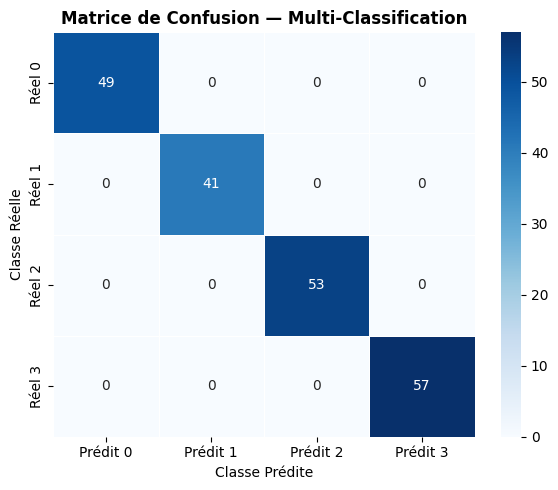

In [86]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'Prédit {i}' for i in range(4)],
    yticklabels=[f'Réel {i}' for i in range(4)],
    ax=ax, linewidths=0.5
)
ax.set_title('Matrice de Confusion — Multi-Classification', fontweight='bold')
ax.set_xlabel('Classe Prédite')
ax.set_ylabel('Classe Réelle')
plt.tight_layout()
plt.show()

### Interprétation des métriques

**Accuracy**

**Formule**

$$
Accuracy = \frac{TP + TN}{Total}
$$

Proportion de prédictions correctes parmi toutes les données.  
Résultat = **1.0000**, soit **100 %**, ce qui signifie que toutes les prédictions sont correctes.

---

**Précision (Precision)**

**Formule**

$$
Precision = \frac{TP}{TP + FP}
$$

Parmi les éléments **prédits positifs**, cette métrique indique combien sont réellement positifs.  
Résultat = **1.0000**, ce qui montre **aucun faux positif**.

---

**Rappel (Recall)**

**Formule**

$$
Recall = \frac{TP}{TP + FN}
$$

Parmi les éléments **réellement positifs**, cette mesure indique combien ont été correctement détectés.  
Résultat = **1.0000**, ce qui signifie **aucun faux négatif**.

---

**F1-Score**

**Formule**

$$
F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}
$$

Moyenne harmonique entre la précision et le rappel.  
Résultat = **1.0000**, confirmant une performance parfaite.

---

**Matrice de confusion**

Toutes les classes (0, 1, 2, 3) ont été correctement prédites, avec **aucune confusion** entre elles.  
Chaque diagonale de la matrice contient la totalité des échantillons de la classe correspondante.

---

> **Interprétation globale :**  
> Les classes sont parfaitement séparées.  
> Le modèle atteint une **performance idéale à 100 %**, sans erreurs de classification.

## 8. Frontières de Décision — Multi-Classification

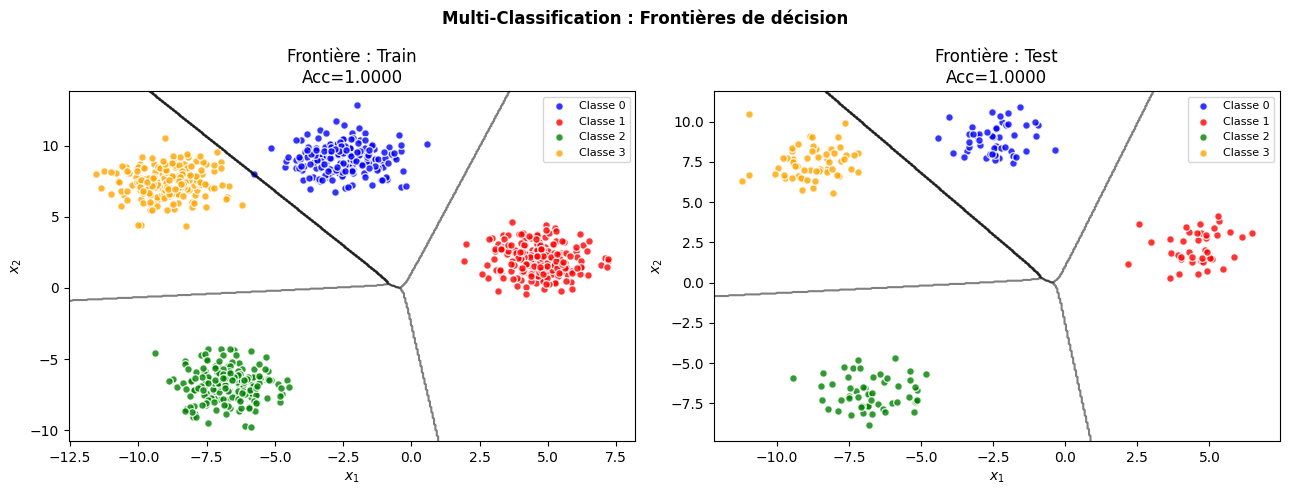

In [87]:
def plot_decision_boundary_mc(model, X, y, title='', ax=None, n_classes=4):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Obtenir la classe prédite pour chaque point de la grille
    Z = np.argmax(model.predict(grid, verbose=0), axis=1).reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # Tracer uniquement les lignes de séparation entre les classes
    ax.contour(xx, yy, Z, levels=np.arange(-0.5, n_classes, 1), colors='black', linewidths=1.5, alpha=0.5)

    # Affichage des points
    colors = ['blue', 'red', 'green', 'orange']
    for cls in range(n_classes):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[cls], label=f'Classe {cls}', edgecolors='white', alpha=0.8, s=30)

    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper right', fontsize=8)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

loss_mc_tr, acc_mc_tr = model_mc.evaluate(X_mc_train, y_mc_train, verbose=0)
loss_mc_te, acc_mc_te = model_mc.evaluate(X_mc_test,  y_mc_test,  verbose=0)

plot_decision_boundary_mc(model_mc, X_mc_train, y_mc_train, title=f'Frontière : Train\nAcc={acc_mc_tr:.4f}', ax=axes[0])
plot_decision_boundary_mc(model_mc, X_mc_test, y_mc_test, title=f'Frontière : Test\nAcc={acc_mc_te:.4f}', ax=axes[1])

plt.suptitle('Multi-Classification : Frontières de décision', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Impact du Nombre d'Échantillons sur l'Accuracy

Nous allons étudier comment l'accuracy de classification évolue lorsqu'on augmente la taille du dataset.

In [88]:
sample_sizes = [50, 100, 200, 500, 1000, 2000]
accuracies_train = []
accuracies_test  = []

for n in sample_sizes:
    X_n, y_n = make_blobs(n_samples=n, n_features=2, centers=4,
                           cluster_std=5, random_state=42)
    X_n_tr, X_n_te, y_n_tr, y_n_te = train_test_split(
        X_n, y_n, test_size=0.2, random_state=42)

    m = Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dense(64, activation='relu'),
        Dense(4,  activation='softmax')
    ])
    m.compile(optimizer=Adam(0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    m.fit(X_n_tr, y_n_tr, epochs=100, batch_size=32, verbose=0)

    _, acc_tr = m.evaluate(X_n_tr, y_n_tr, verbose=0)
    _, acc_te = m.evaluate(X_n_te, y_n_te, verbose=0)
    accuracies_train.append(acc_tr)
    accuracies_test.append(acc_te)

    print(f'n={n:6d} | Train Acc={acc_tr:.4f} | Test Acc={acc_te:.4f}')

print('\nAnalyse terminée.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


n=    50 | Train Acc=0.7500 | Test Acc=0.8000
n=   100 | Train Acc=0.7625 | Test Acc=0.8000
n=   200 | Train Acc=0.7750 | Test Acc=0.7250
n=   500 | Train Acc=0.7400 | Test Acc=0.7600
n=  1000 | Train Acc=0.7325 | Test Acc=0.6950
n=  2000 | Train Acc=0.7387 | Test Acc=0.7325

Analyse terminée.


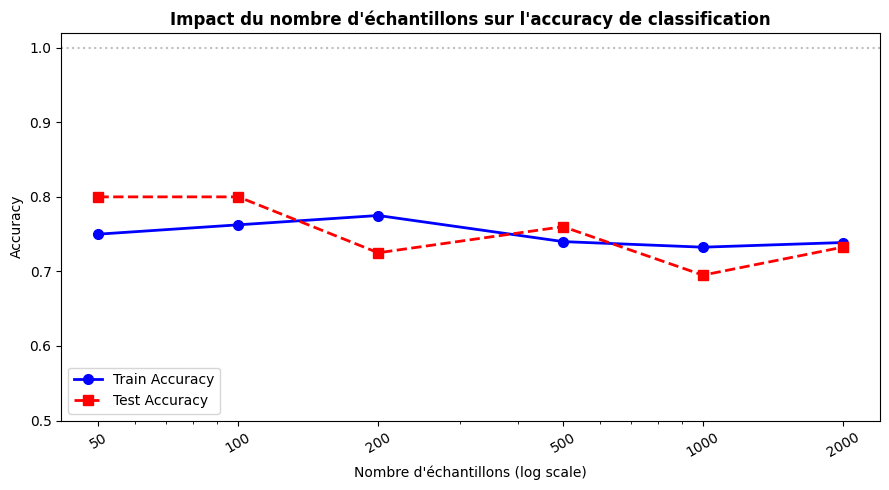

In [89]:
plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, accuracies_train, marker='o', label='Train Accuracy',
         color='blue', linewidth=2, markersize=7)
plt.plot(sample_sizes, accuracies_test,  marker='s', label='Test Accuracy',
         color='red',    linewidth=2, markersize=7, linestyle='--')
plt.xscale('log')
plt.xticks(sample_sizes, [str(n) for n in sample_sizes], rotation=30)
plt.xlabel('Nombre d\'échantillons (log scale)')
plt.ylabel('Accuracy')
plt.title('Impact du nombre d\'échantillons sur l\'accuracy de classification', fontweight='bold')
plt.ylim([0.5, 1.02])
plt.axhline(y=1.0, color='grey', linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



### Analyse de l'impact du nombre d'échantillons

> **Remarque :** Pour générer ces résultats, j'ai augmenté `cluster_std`  à **5**, sinon les performances seraient quasi parfaites pour toutes les tailles d’échantillons.  

---

## Observations

- Pour les petits jeux de données, l’accuracy reste relativement stable.  
- Avec l’augmentation du nombre d’échantillons et le chevauchement accru, la performance fluctue et tend à légèrement diminuer.  
- Pour n = 2000, le modèle atteint une stabilité autour de **73–74 % accuracy**.

> On peut conclure que l'augmentation du nombre d'échantillons, combinée à un chevauchement  entre les classes, rend la tâche de classification plus difficile.  
> Cela explique la légère baisse de l'accuracy, montrant que même un modèle performant peut être affecté par la complexité ou/et la densité des données.

---
# Conclusions Générales

1. On commence toujours par **visualiser les données** avant de choisir l’architecture du modèle.  
2. On **préfère ReLU** dans les couches cachées et **Softmax ou Sigmoïde** en sortie .  
3. On **utilise Adam** comme optimiseur par défaut.  
4. On **trace les courbes d’apprentissage** pour voir si le modèle sur-apprend ou sous-apprend.  
